### Ethiopian Birr Banknote Denomination Recognition Using CNN

This project uses a Convolutional Neural Network (CNN) to recognize Ethiopian Birr banknote denominations from images.

The model classifies banknotes into five denominations:
- 5 Birr
- 10 Birr
- 50 Birr
- 100 Birr
- 200 Birr

The dataset contains images of both the front and back of each banknote. The goal is to train, evaluate, and save a deep learning model that can automatically identify the denomination of a given banknote image.

#### Import the libraries

In [1]:
! pip install numpy tensorflow pandas matplotlib seaborn scikit-learn Pillow
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
TensorFlow version: 2.21.0


#### Define Dataset Path

In [2]:
TRAIN_DIR = "../data/Ethiopian_Currency/train"
TEST_DIR = "../data/Ethiopian_Currency/test"

print("Training directory exists:", os.path.exists(TRAIN_DIR))
print("Testing directory exists:", os.path.exists(TEST_DIR))

Training directory exists: True
Testing directory exists: True


#### Explore the folders

In [3]:
print("Training folders:")
print(os.listdir(TRAIN_DIR))

print("\nTesting folders:")
print(os.listdir(TEST_DIR))

Training folders:
['background', '10back', '.DS_Store', '100back', '200front', '10front', '50front', '200back', '50back', '5back', '100front', '5front']

Testing folders:
['background', '10back', '.DS_Store', '100back', '200front', '10front', '50front', '200back', '50back', '5back', '100front', '5front']


#### Count the images


In [4]:
def count_images(directory):
    counts = {}

    for folder in sorted(os.listdir(directory)):
        folder_path = os.path.join(directory, folder)

        if os.path.isdir(folder_path):
            counts[folder] = len([
                file for file in os.listdir(folder_path)
                if file.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:")
for folder, count in train_counts.items():
    print(f"{folder}: {count}")

print("\nTesting images:")
for folder, count in test_counts.items():
    print(f"{folder}: {count}")

Training images:
100back: 148
100front: 148
10back: 148
10front: 148
200back: 148
200front: 148
50back: 148
50front: 148
5back: 148
5front: 148
background: 64

Testing images:
100back: 36
100front: 36
10back: 36
10front: 36
200back: 36
200front: 36
50back: 36
50front: 36
5back: 36
5front: 36
background: 15


#### Visualize the dataset

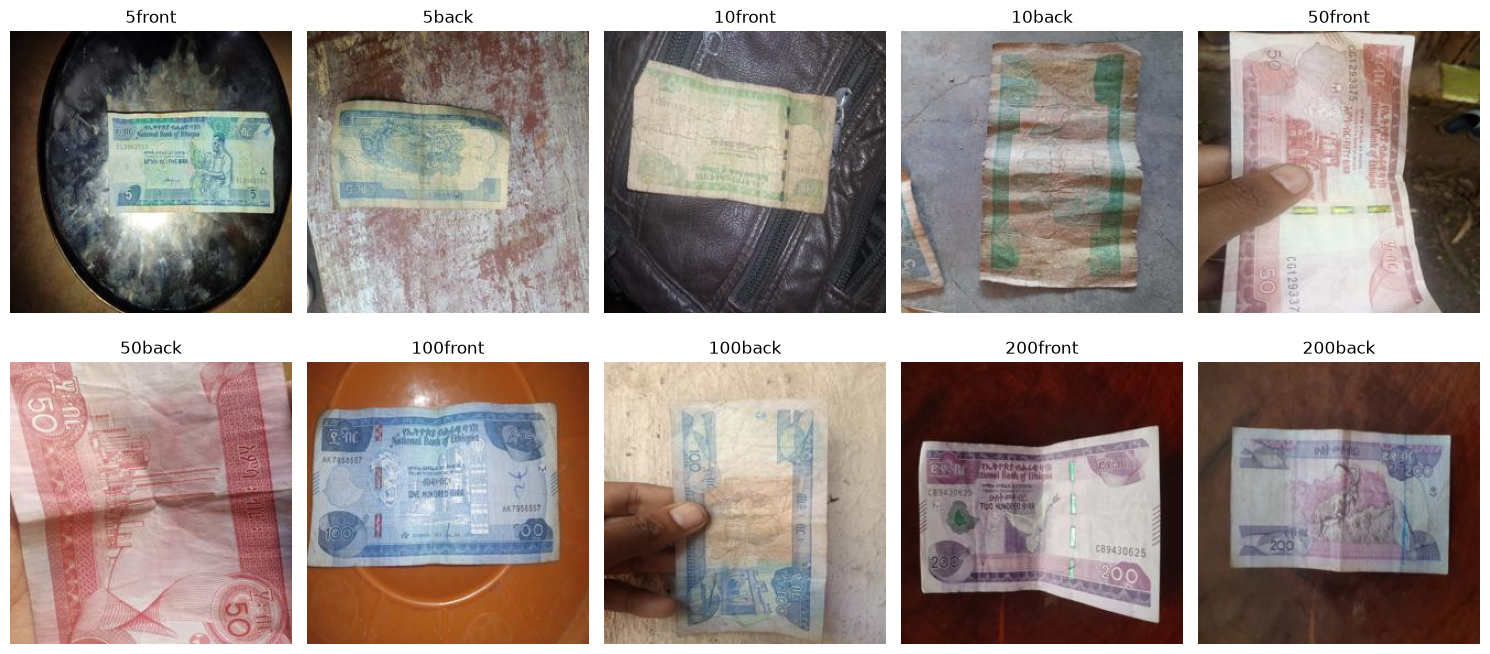

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

folders = [
    "5front",
    "5back",
    "10front",
    "10back",
    "50front",
    "50back",
    "100front",
    "100back",
    "200front",
    "200back"
]

for ax, folder in zip(axes.flatten(), folders):
    folder_path = os.path.join(TRAIN_DIR, folder)

    images = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(folder_path, images[0])
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(folder)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Label Mapping

In [6]:
CLASS_MAPPING = {
    "5front": 0,
    "5back": 0,

    "10front": 1,
    "10back": 1,

    "50front": 2,
    "50back": 2,

    "100front": 3,
    "100back": 3,

    "200front": 4,
    "200back": 4
}

CLASS_NAMES = [
    "5 Birr",
    "10 Birr",
    "50 Birr",
    "100 Birr",
    "200 Birr"
]

#### Choose Image Size

In [7]:
IMG_SIZE = (224, 224)

#### Load the images

In [8]:
def load_images(directory, class_mapping):
    images = []
    labels = []

    for folder in os.listdir(directory):

        folder_path = os.path.join(directory, folder)

        if not os.path.isdir(folder_path):
            continue

        # Skip background images
        if folder == "background":
            continue

        # Get the label from our mapping
        label = class_mapping[folder]

        for filename in os.listdir(folder_path):

            if filename.lower().endswith((".jpg", ".jpeg", ".png")):

                image_path = os.path.join(folder_path, filename)

                try:
                    image = Image.open(image_path).convert("RGB")
                    image = image.resize(IMG_SIZE)

                    images.append(np.array(image))
                    labels.append(label)

                except Exception as e:
                    print(f"Could not load {image_path}: {e}")

    return np.array(images), np.array(labels)

#### Load Training and Testing Dataset

In [9]:
X_train, y_train = load_images(TRAIN_DIR, CLASS_MAPPING)
X_test, y_test = load_images(TEST_DIR, CLASS_MAPPING)

In [10]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1480, 224, 224, 3)
y_train shape: (1480,)
X_test shape: (360, 224, 224, 3)
y_test shape: (360,)


#### Normalize the images

In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [12]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


#### Class Distribution

In [13]:
# Training Set
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{CLASS_NAMES[label]}: {count}")

5 Birr: 296
10 Birr: 296
50 Birr: 296
100 Birr: 296
200 Birr: 296


In [14]:
# Testing Set
unique, counts = np.unique(y_test, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{CLASS_NAMES[label]}: {count}")

5 Birr: 72
10 Birr: 72
50 Birr: 72
100 Birr: 72
200 Birr: 72


- Both the training and testing sets are balanced.

#### Create a validation set

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [16]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (1184, 224, 224, 3) (1184,)
Validation: (296, 224, 224, 3) (296,)
Testing: (360, 224, 224, 3) (360,)


#### Data Augmentation

In [17]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
], name="data_augmentation")

#### Visualize augmentation

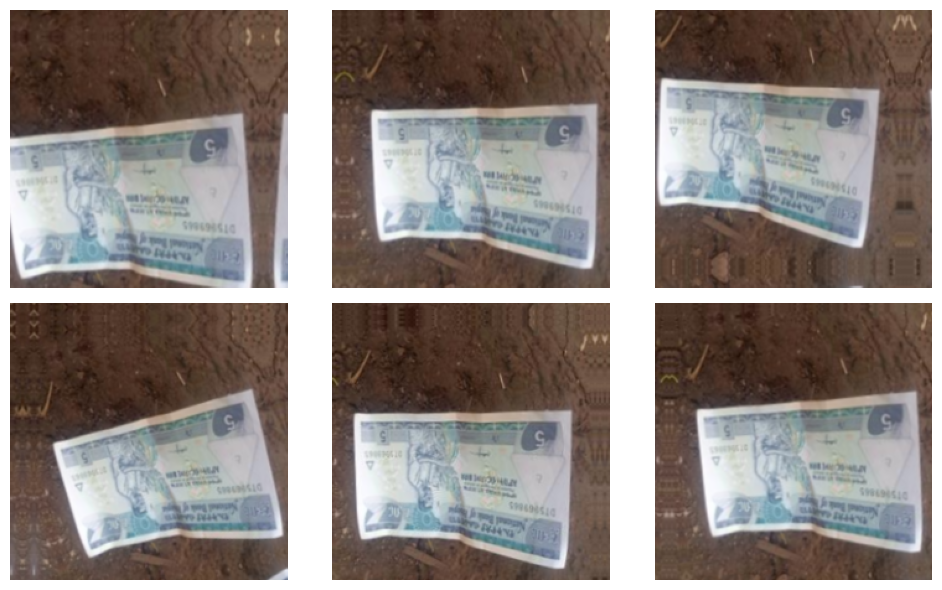

In [18]:
plt.figure(figsize=(10, 6))

sample_image = X_train[0]

for i in range(6):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image[0])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Build the CNN

In [19]:
model = keras.Sequential([
    
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(5, activation="softmax")
])

#### Examine the model

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

#### Compile the model

In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#### Train the CNN

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 968ms/step - accuracy: 0.5507 - loss: 1.1137 - val_accuracy: 0.2095 - val_loss: 1.6440
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7289 - loss: 0.7516 - val_accuracy: 0.2027 - val_loss: 1.8232
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7829 - loss: 0.6084 - val_accuracy: 0.1993 - val_loss: 2.3124
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7914 - loss: 0.5627 - val_accuracy: 0.2736 - val_loss: 2.2932
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8226 - loss: 0.4686 - val_accuracy: 0.2703 - val_loss: 2.2797
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8446 - loss: 0.4297 - val_accuracy: 0.2027 - val_loss: 2.3027
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8395 - loss: 0.4214 - val_accuracy: 0.2365 - val_loss: 2.2951
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8716 - loss: 0.3552 - val_accuracy: 0.2770 - val_lo

#### Plot training performance

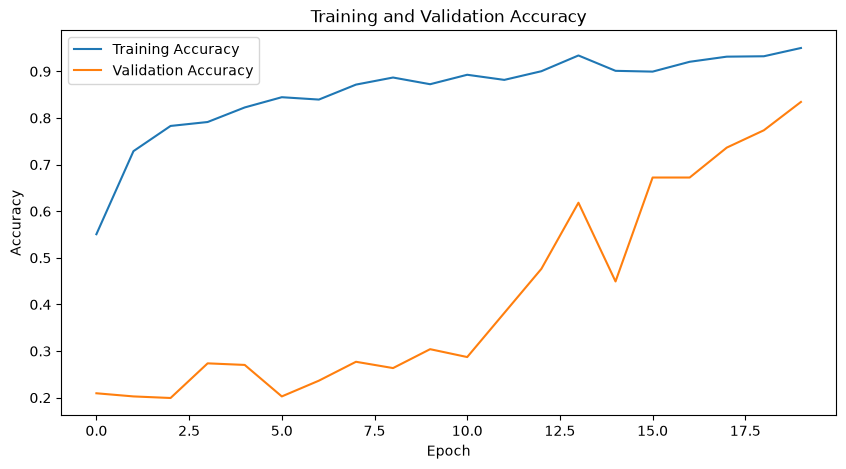

In [24]:
# Accuracy
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

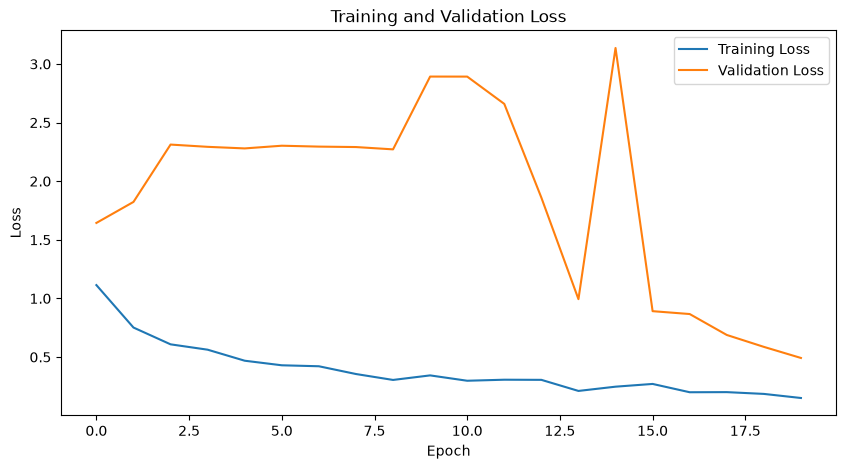

In [25]:
# Loss
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

#### Evaluate on test set

In [26]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - accuracy: 0.8333 - loss: 0.4427
Test Loss: 0.44272205233573914
Test Accuracy: 0.8333333134651184


#### Predictions

In [27]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step


#### Classification Report

In [28]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES
    )
)

              precision    recall  f1-score   support

      5 Birr       0.88      0.49      0.62        72
     10 Birr       1.00      0.85      0.92        72
     50 Birr       0.89      0.92      0.90        72
    100 Birr       0.65      0.94      0.77        72
    200 Birr       0.86      0.97      0.92        72

    accuracy                           0.83       360
   macro avg       0.86      0.83      0.83       360
weighted avg       0.86      0.83      0.83       360



#### Confusion Matrix

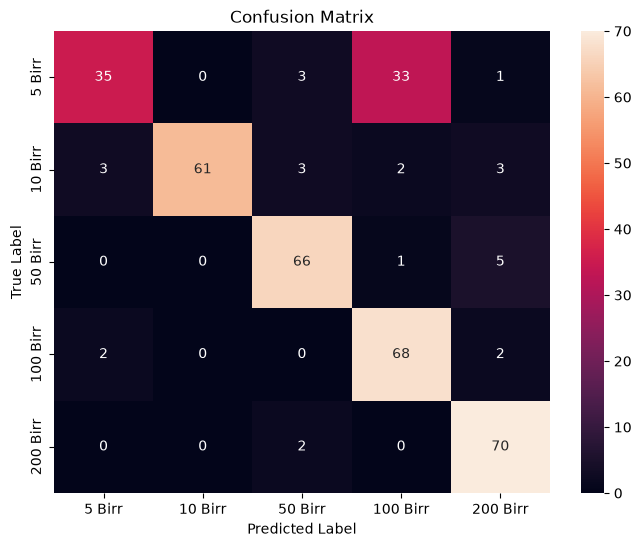

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()